In [49]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns
matplotlib_font_size=7
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = matplotlib_font_size


path_figures=Path().cwd().parent.parent/"figures"
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data=Path.cwd().parent.parent/"benchmark_search_performance"
path_benchmark_data.mkdir(parents=True, exist_ok=True)

In [50]:
steps=[
    "open_search", 
    "neutral_loss_search",
    "hybrid_search"
    ]

lib_size=[1_000_000, 2_000_000, 10_000_000, 30_000_000, 100_000_000]
query_size=100
ion_mode=[-1, 1]


In [51]:
df=[]
for charge in ion_mode:
    for library_size in lib_size:
        for i in range(query_size):
            data={"total_library_number":library_size, "query_idx":i, "charge":charge}
            
            for step in steps:       
                
                
                path_benchmark_dynamic_fast_update=path_benchmark_data/f"dynamic_fast_update_{charge}_{library_size}_memory_usage_{step}_step_query_{i}.txt"
                path_benchmark_dynamic_convert_to_flash=path_benchmark_data/f"dynamic_convert_to_flash_{charge}_{library_size}_memory_usage_{step}_step_query_{i}.txt"
                

                try:
                    path_benchmark_masstplus=path_benchmark_data/f"masstplus_{charge}_{library_size}_memory_usage_{step}_step_query_{i}.txt"
                    with open(path_benchmark_masstplus,"r") as f:    
                        for line in f.readlines():
                            items=line.split(":", maxsplit=1)
                            key, value=items
                            if key.strip()=="Maximum resident set size (kbytes)":
                                masstplus=int(value.strip())
                    data["masstplus"]=masstplus/1048576
                except:
                    data["masstplus"]=None
 

                with open(path_benchmark_dynamic_fast_update,"r") as f:
                    for line in f.readlines():
                        items=line.split(":", maxsplit=1)
                        key, value=items
                        if key.strip()=="Maximum resident set size (kbytes)":
                            dynamic_fast_update=int(value.strip())


                with open(path_benchmark_dynamic_convert_to_flash,"r") as f:
                    for line in f.readlines():
                        items=line.split(":", maxsplit=1)
                        key, value=items
                        if key.strip()=="Maximum resident set size (kbytes)":
                            dynamic_convert_to_flash=int(value.strip())

                try:
                    path_benchmark_flash=path_benchmark_data/f"flash_{charge}_{library_size}_memory_usage_{step}_step_query_{i}.txt"

                    with open(path_benchmark_flash,"r") as f:    
                        for line in f.readlines():
                            items=line.split(":", maxsplit=1)
                            key, value=items
                            if key.strip()=="Maximum resident set size (kbytes)":
                                flash=int(value.strip())
                    data["flash_entropy_search"]=flash/1048576
                except:
                    data["flash_entropy_search"]=None


                # data["dynamic_entropy_search(fast_search)"]=dynamic_fast_search/1048576
                data["dynamic_entropy_search(fast_update)"]=dynamic_fast_update/1048576
                data["dynamic_entropy_search(convert_to_flash)"]=dynamic_convert_to_flash/1048576
                
                data["search_type"]=step 


                df.append(pd.DataFrame([data]))
                
df=pd.concat(df)

df


,total_library_number,query_idx,charge,masstplus,flash_entropy_search,dynamic_entropy_search(fast_update),dynamic_entropy_search(convert_to_flash),search_type
0,1000000,0,-1,None,0.046642,0.046234,0.049633,open_search
0,1000000,0,-1,None,0.050053,0.050751,0.053413,neutral_loss_search
0,1000000,0,-1,0.210148,0.068951,0.063885,0.068565,hybrid_search
0,1000000,1,-1,None,0.043312,0.039024,0.046528,open_search
0,1000000,1,-1,None,0.049732,0.046043,0.051739,neutral_loss_search
...,...,...,...,...,...,...,...,...
0,100000000,98,1,None,None,0.776649,0.868416,neutral_loss_search
0,100000000,98,1,None,None,0.903927,1.046425,hybrid_search
0,100000000,99,1,None,None,0.776230,0.781429,open_search
0,100000000,99,1,None,None,0.776417,0.783173,neutral_loss_search


In [52]:

df_data = df[["search_type", 
              "total_library_number",
            "dynamic_entropy_search(fast_update)",
            "dynamic_entropy_search(convert_to_flash)", 
            "flash_entropy_search",
            "masstplus",
            "charge"]]
    
df_melted=df_data.melt(id_vars=["charge", "search_type",  "total_library_number"], var_name="method", value_name="memory_usage")
df_melted        
df_melted['total_library_number'] = pd.to_numeric(df_melted['total_library_number'])
df_melted


,charge,search_type,total_library_number,method,memory_usage
0,-1,open_search,1000000,dynamic_entropy_search(fast_update),0.046234
1,-1,neutral_loss_search,1000000,dynamic_entropy_search(fast_update),0.050751
2,-1,hybrid_search,1000000,dynamic_entropy_search(fast_update),0.063885
3,-1,open_search,1000000,dynamic_entropy_search(fast_update),0.039024
4,-1,neutral_loss_search,1000000,dynamic_entropy_search(fast_update),0.046043
...,...,...,...,...,...
11995,1,neutral_loss_search,100000000,masstplus,None
11996,1,hybrid_search,100000000,masstplus,None
11997,1,open_search,100000000,masstplus,None
11998,1,neutral_loss_search,100000000,masstplus,None


In [53]:
def plot_memory_different_search_methods(
        df_melted,
        charge,
        search_type,
        hue_order,
        ylim,
        color_palette,
        save_path
):
    df_charge=df_melted[df_melted["charge"]==charge]
    df_plot=df_charge[df_charge["search_type"]==search_type]

    fig, ax = plt.subplots(figsize=(3, 2))
    ax.grid(True, which="both", axis="y", ls="-", alpha=0.5, linewidth=0.4)
    if charge==1:
        ion_mode="+"
    elif charge==-1:
        ion_mode="-"
    ax.set_title(f'{search_type.replace("_"," ").title()} (({ion_mode})ESI)', fontsize=matplotlib_font_size)
    sns.stripplot(x="total_library_number", y="memory_usage", hue="method", data=df_plot, hue_order=hue_order, palette=color_palette, dodge=True, jitter=0.25, size=1, alpha=0.8, linewidth=0, ax=ax, legend=False)     
    
    sns.boxplot(x="total_library_number", y="memory_usage", hue="method", data=df_plot, hue_order=hue_order, dodge=True, palette=color_palette, linewidth=0.4, width=0.9, boxprops={"alpha":0.75}, ax=ax, fliersize=0, legend=False)
    ax.set_yscale("log")
    bottom=ylim[0]
    top=ylim[1]
    ax.set_ylim(top=top, bottom=bottom)
    ax.set_ylabel("Library Search Memory Usage (GB)")
    for spine in ax.spines.values():  
        spine.set_linewidth(0.4)
    ax.tick_params(which="both", width=0.4)    
    ax.set_xlabel("Library size")
    legend_labels = {
    "dynamic_entropy_search(fast_update)": "Dynamic Entropy Search", 
    "dynamic_entropy_search(convert_to_flash)": "Dynamic Entropy Search (with index converted)",
    "flash_entropy_search": "Flash Entropy Search",
    "masstplus": "MASST+"
    }
    handles = []
    for method in hue_order:
        handle = plt.Line2D([0], [0], marker='o', color=color_palette[method], 
                       markersize=3, linestyle='',label=legend_labels.get(method, method))
        handles.append(handle)

    fig.legend(handles=handles, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 1.2), 
           ncol=4, 
           fontsize=matplotlib_font_size,
           frameon=False)    
    
    current_labels = [int(label.get_text()) for label in ax.get_xticklabels()]
    formatted_labels = [f"{label:,}" for label in current_labels]
    ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=matplotlib_font_size)

    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1, dpi=1200)

In [54]:
# my_color_palette=['#008F85', '#289CD9', "#D38F88", "#B3A7CC"]
my_color_palette=sns.color_palette("Set3", 12)
# color_palette={
#     "dynamic_entropy_search(fast_update)": my_color_palette[0],
#     "dynamic_entropy_search(convert_to_flash)": my_color_palette[-1],
#     "flash_entropy_search": my_color_palette[1],
#     "masstplus": my_color_palette[2],
# }
color_palette={
    
    "dynamic_entropy_search(fast_update)": my_color_palette[4],
    "dynamic_entropy_search(convert_to_flash)": my_color_palette[6],
    "flash_entropy_search":my_color_palette[3],
    "masstplus":my_color_palette[-3]

}
hue_order=["dynamic_entropy_search(fast_update)", "dynamic_entropy_search(convert_to_flash)", "flash_entropy_search", "masstplus"]


/tmp/ipykernel_27438/1454078788.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=matplotlib_font_size)


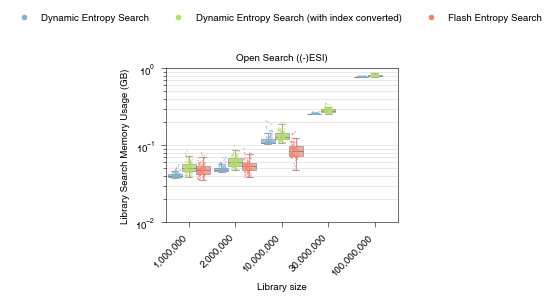

In [55]:
charge=-1
search_type='open_search'
ylim=(1e-2,1e0)
save_path=path_figures / f"compare_memory_usage_{search_type}_methods_charge_{charge}.svg"
plot_memory_different_search_methods(
    df_melted=df_melted,
    charge=charge,
    search_type=search_type,
    hue_order=hue_order[:-1],
    ylim=ylim,
    color_palette=color_palette,
    save_path=save_path
)

/tmp/ipykernel_27438/1454078788.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=matplotlib_font_size)


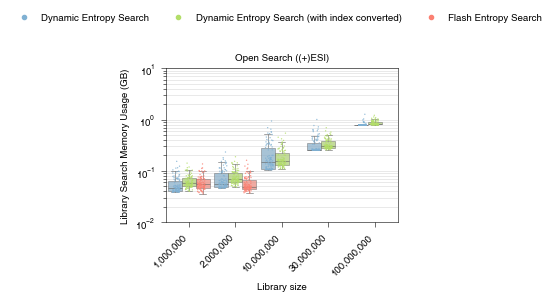

In [56]:
charge=1
search_type='open_search'
ylim=(1e-2,1e1)
save_path=path_figures / f"compare_memory_usage_{search_type}_methods_charge_{charge}.svg"
plot_memory_different_search_methods(
    df_melted=df_melted,
    charge=charge,
    search_type=search_type,
    hue_order=hue_order[:-1],
    ylim=ylim,
    color_palette=color_palette,
    save_path=save_path
)

/tmp/ipykernel_27438/1454078788.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=matplotlib_font_size)


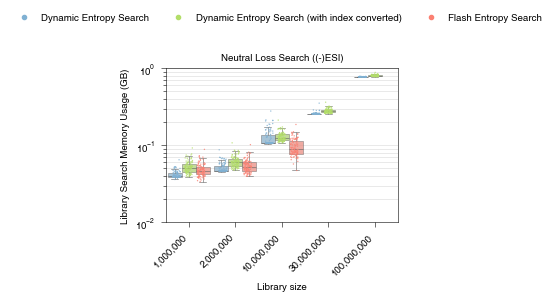

In [57]:
charge=-1
search_type='neutral_loss_search'
ylim=(1e-2,1e0)
save_path=path_figures / f"compare_memory_usage_{search_type}_methods_charge_{charge}.svg"
plot_memory_different_search_methods(
    df_melted=df_melted,
    charge=charge,
    search_type=search_type,
    hue_order=hue_order[:-1],
    ylim=ylim,
    color_palette=color_palette,
    save_path=save_path
)

/tmp/ipykernel_27438/1454078788.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=matplotlib_font_size)


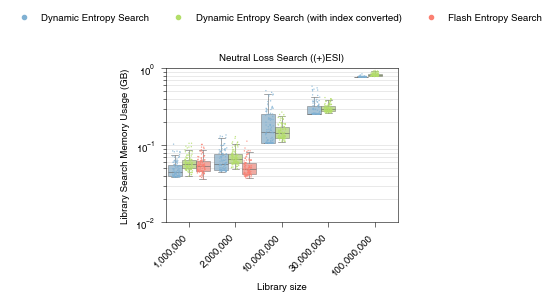

In [58]:
charge=1
search_type='neutral_loss_search'
ylim=(1e-2,1e0)
save_path=path_figures / f"compare_memory_usage_{search_type}_methods_charge_{charge}.svg"
plot_memory_different_search_methods(
    df_melted=df_melted,
    charge=charge,
    search_type=search_type,
    hue_order=hue_order[:-1],
    ylim=ylim,
    color_palette=color_palette,
    save_path=save_path
)

/tmp/ipykernel_27438/1454078788.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=matplotlib_font_size)


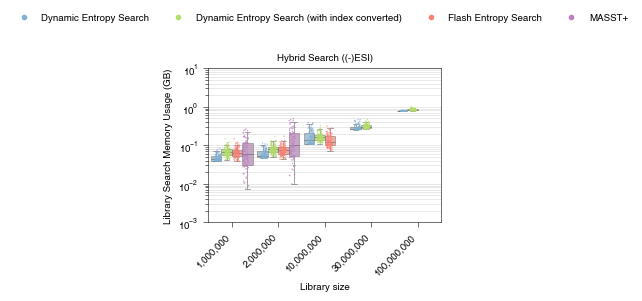

In [59]:
charge=-1
search_type='hybrid_search'
ylim=(1e-3,1e1)
save_path=path_figures / f"compare_memory_usage_{search_type}_methods_charge_{charge}.svg"
plot_memory_different_search_methods(
    df_melted=df_melted,
    charge=charge,
    search_type=search_type,
    hue_order=hue_order,
    ylim=ylim,
    color_palette=color_palette,
    save_path=save_path
)

/tmp/ipykernel_27438/1454078788.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=matplotlib_font_size)


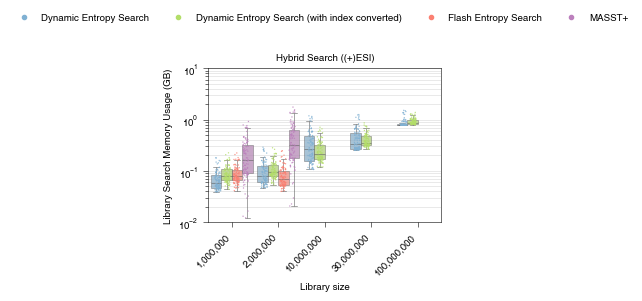

In [60]:
charge=1
search_type='hybrid_search'
ylim=(1e-2,1e1)
save_path=path_figures / f"compare_memory_usage_{search_type}_methods_charge_{charge}.svg"
plot_memory_different_search_methods(
    df_melted=df_melted,
    charge=charge,
    search_type=search_type,
    hue_order=hue_order,
    ylim=ylim,
    color_palette=color_palette,
    save_path=save_path
)